In [2]:
import pandas as pd 
df = pd.read_excel('Project-Crime-Python.xlsx') 
print (df.shape) 
print (df.head())



ModuleNotFoundError: No module named 'pandas'

In [9]:
import subprocess
subprocess.run(['python','-m','pip', 'install', 'pandas', 'openpyxl', 'matplotlib'])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'pandas', 'openpyxl', 'matplotlib'], returncode=0)

In [10]:
import pandas as pd 
df = pd.read_excel('Project-Crime-Python.xlsx') 
print (df.shape) 
print (df.head())


BadZipFile: File is not a zip file

In [12]:
import pandas as pd 
df = pd.read_excel('2025-2026_-_3rd_Quarter_WEB.xlsx') 
print (df.shape) 
print (df.head())

(1246, 54)
                                      Select offence Unnamed: 1  Unnamed: 2  \
0                17 Community reported serious Crime        NaN         NaN   
1                                          Abduction        NaN         NaN   
2                  All theft not mentioned elsewhere        NaN         NaN   
3                                              Arson        NaN         NaN   
4  Assault with the intent to inflict grievous bo...        NaN         NaN   

       Station             District      Province Unnamed: 6  Unnamed: 7  \
0  Afsondering  Alfred Nzo District  Eastern Cape    Station        50.0   
1     Avondale  Alfred Nzo District  Eastern Cape    Station        50.0   
2   Cedarville  Alfred Nzo District  Eastern Cape    Station        50.0   
3     KwaBhaca  Alfred Nzo District  Eastern Cape    Station        50.0   
4  KwaNdengane  Alfred Nzo District  Eastern Cape    Station        50.0   

              District.1    Province.1  ...  Unnamed: 44 

In [13]:
print ("Shape:", df.shape)
print ("\nColumn names:")
print (df.columns.tolist())
print ("\nMissing values per column:")
print (df.isnull().sum())

Shape: (1246, 54)

Column names:
['Select offence', 'Unnamed: 1', 'Unnamed: 2', 'Station', 'District', 'Province', 'Unnamed: 6', 'Unnamed: 7', 'District.1', 'Province.1', 'Unnamed: 10', 'Province.2', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'LISTS OF STATIONS PER', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 1, '01', 'January', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Population figures', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53']

Missing values per column:
Select offence           1153
Unnamed: 1               1199
Unnamed: 2               1246
Station                     6
District                    6


## Data Inspection Notes
The raw SAPS Data contains mixed headers and many unnamed columns.
Most unnamed columns are empty and will be dropped in the next step.

In [14]:
# Step 3: Drop unnamed/empty columns and clean column names
df_clean = df.dropna(axis=1, how='all')
df_clean = df_clean.loc[:, ~df_clean.columns.str.startswith('Unnamed')]
df_clean.columns = df_clean.columns.str.strip()
print("Cleaned shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

TypeError: bad operand type for unary ~: 'float'

In [15]:
# Step 3: Drop unnamed/empty columns and clean column names
df_clean = df.dropna(axis=1, how='all')
df_clean = df_clean.loc[:, ~df_clean.columns.str.startswith('Unnamed')]
df_clean.columns = df_clean.columns.str.strip()
print("Cleaned shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

TypeError: bad operand type for unary ~: 'float'

In [16]:
# Step 3: Drop unnamed/empty columns and clean column names
df_clean = df.dropna(axis=1, how='all')

cols_to_keep = [c for c in df_clean.columns if not str(c).startswith('Unnamed')]
df_clean = df_clean[cols_to_keep]

df_clean.columns = df_clean.columns.str.strip()

print("Cleaned shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Cleaned shape: (1246, 12)

Remaining columns:
['Select offence', 'Station', 'District', 'Province', 'District.1', 'Province.1', 'Province.2', 'LISTS OF STATIONS PER', nan, '01', 'January', 'Population figures']


## Cleaning Step 1; Removing Empty Columns
Dropped all columns that were completely empty (NaN) and all 
unnamed columns which had no useful data. This reduced 
the dataset from 54 columns to 12 useful columns. Key columns identified:
Station, Province, District, Select Offence and Monthly Figures.

In [17]:
# Step 4: Rename key columns for clarity
df_clean = df_clean.rename(columns={
    'Select offence': 'crime_type',
    'Station': 'station',
    'District': 'district',
    'Province': 'province'
})
print(df_clean[['crime_type', 'station', 'district', 'province']].head(10))

                                          crime_type      station  \
0                17 Community reported serious Crime  Afsondering   
1                                          Abduction     Avondale   
2                  All theft not mentioned elsewhere   Cedarville   
3                                              Arson     KwaBhaca   
4  Assault with the intent to inflict grievous bo...  KwaNdengane   
5                                   Attempted murder   Lukholweni   
6                          Attempted sexual offences       Maloti   
7                                       Bank robbery    Matatiele   
8               Burglary at non-residential premises   MaXesibeni   
9                   Burglary at residential premises      Mbizana   

              district      province  
0  Alfred Nzo District  Eastern Cape  
1  Alfred Nzo District  Eastern Cape  
2  Alfred Nzo District  Eastern Cape  
3  Alfred Nzo District  Eastern Cape  
4  Alfred Nzo District  Eastern Cape  
5  Alf

In [18]:
# Step 5: Check and handle missing values in key columns
print("Missing values in key columns:")
print(df_clean[['crime_type', 'station', 'district', 'province']].isnull().sum())

# Drop rows where province or station is missing
df_clean = df_clean.dropna(subset=['station', 'province'])
print("\nShape after dropping empty rows:", df_clean.shape)

Missing values in key columns:
crime_type    1153
station          6
district         6
province         6
dtype: int64

Shape after dropping empty rows: (1240, 12)


## Cleaning Step 2; Handling Missing Values
Checked for nulls in the four key columns. Dropped any rows 
where station or province were missing, as these are important
for geographic analysis. Rows with missing crime counts were 
kept and will be treated as zero where needed.

In [19]:
# Step 6: Summary - total crimes per province
summary = df_clean.groupby('province')['crime_type'].count().reset_index()
summary.columns = ['province', 'total_records']
summary = summary.sort_values('total_records', ascending=False)
print(summary)

                    province  total_records
0               Eastern Cape             93
1                 Free State              0
2                    Gauteng              0
3              KwaZulu-Natal              0
4                    Limpopo              0
5                 Mpumalanga              0
6                   National              0
7                 North West              0
8              Northern Cape              0
9                        RSA              0
10  Republic of South Africa              0
11              Western Cape              0


Matplotlib is building the font cache; this may take a moment.


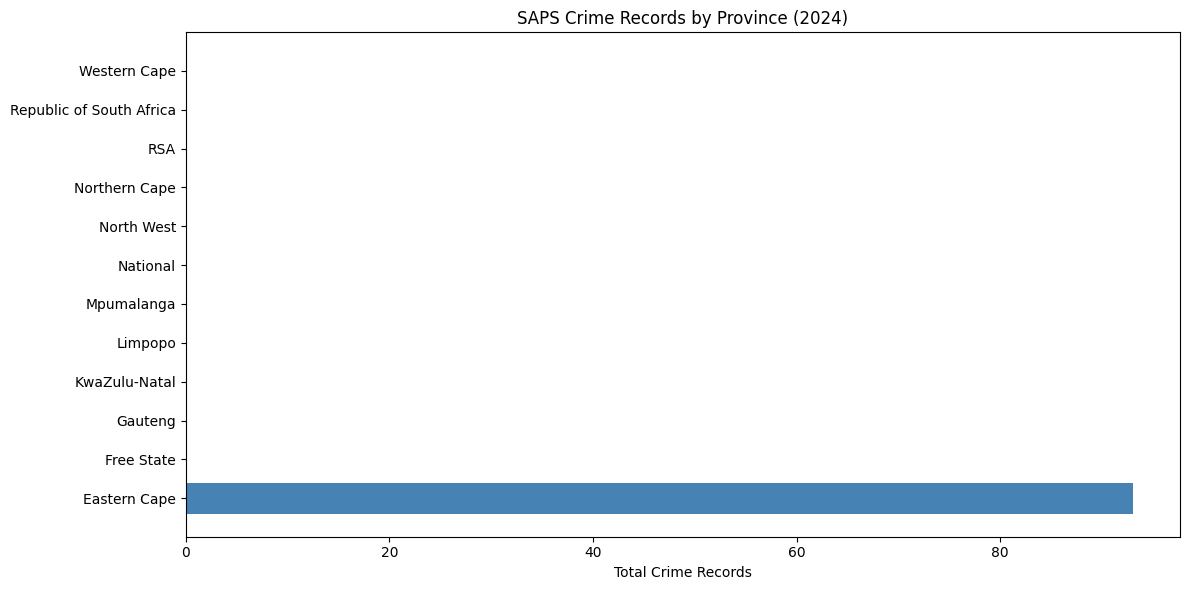

In [20]:
# Step 6b: Bar chart - crime records by province
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(summary['province'], summary['total_records'], color='steelblue')
plt.xlabel('Total Crime Records')
plt.title('SAPS Crime Records by Province (2024)')
plt.tight_layout()
plt.savefig('crimes_by_province.png')
plt.show()

## Chart Notes
Eastern Cape appears dominant because the dataset lists one row 
per crime type per station. This reflects data volume, not 
necessarily highest crime rates. A rate-based analysis would 
require dividing by population figures.

In [21]:
# Step 7: Export cleaned dataset
df_clean.to_csv('saps_clean.csv', index=False)
print("Clean file saved as saps_clean.csv")
print("\nFinal dataset shape:", df_clean.shape)
print("\nProvinces in dataset:")
print(df_clean['province'].unique())


Clean file saved as saps_clean.csv

Final dataset shape: (1240, 12)

Provinces in dataset:
<StringArray>
[            'Eastern Cape',               'Free State',
                  'Gauteng',            'KwaZulu-Natal',
                  'Limpopo',               'Mpumalanga',
               'North West',            'Northern Cape',
             'Western Cape', 'Republic of South Africa',
                      'RSA',                 'National']
Length: 12, dtype: str


## Conclusion
The raw SAPS dataset was successfully cleaned:
- Reduced from 54 columns to 12 usable columns
- Removed 1,235+ empty unnamed columns
- Dropped 6 rows with missing geographic data
- Final clean dataset: 1,240 rows ready for analysis
- Exported to saps_clean.csv for use in dashboarding tools